In [ ]:
import sys
import os
# Add the parent directory to the Python path
sys.path.append(os.path.abspath('..'))
from simu_PSF_polarMFM_JAX import *
from simu_PSF_polarMFM import *
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import torch

print(jax.devices())

2026-08-04 14:23:28.823811: W external/xla/xla/service/gpu/nvptx_compiler.cc:765] The NVIDIA driver's CUDA version is 12.6 which is older than the ptxas CUDA version (12.9.86). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


[cuda(id=0)]


In [90]:
N_photons=jax.device_put(1000) # number of photons collected 
N=jax.device_put(80) # discretization of the BFP
l_pixel=jax.device_put(4) #pixel size in micrometer
NA=jax.device_put(1.4) # numerical aperture
mag=jax.device_put(100) # first magnification
lambd=jax.device_put(617) # wavelength
f_tube=jax.device_put(200) # tube lens focal
MAG=jax.device_put(200/150) # second magnification

In [91]:
def rot(angle):
    angle=angle*jnp.pi/180
    return jnp.array([[jnp.cos(angle), -jnp.sin(angle)],[jnp.sin(angle), jnp.cos(angle)]])
J1 = jnp.array([[ 0.89642966        ,             -0.15750188 + 1j*  -0.41388938 ],[
      -0.22662663 + 1j*  0.37517267  ,   -0.88134384 + 1j*  -0.17010298 ]])
J2 = jnp.array([[ 0.5655862               ,      -0.77402043 + 1j*  0.27935567 ],[
      0.42339513 + 1j*  -0.7021969   ,  0.11452306 + 1j*  -0.5653576 ]])
J_dichroic = np.array([J1, J2, J1])
J_dichroic = np.array([jnp.eye(2), rot(45)@jnp.eye(2), jnp.eye(2)])

In [92]:
SAF = True

In [93]:
if SAF:
    x, y, th1, phi, (Ex0, Ex1, Ex2), (Ey0, Ey1, Ey2), r, r_cut, r_cut_SAF, k, f_o, cos_th2 = vectorial_BFP_perfect_focus_jax(N, NA, mag, lambd, f_tube, J_dichroic=J_dichroic, SAF=SAF)
else:
    cos_th2=None
    x, y, th1, phi, (Ex0, Ex1, Ex2), (Ey0, Ey1, Ey2), r, r_cut, k, f_o = vectorial_BFP_perfect_focus_jax(N, NA, mag, lambd, f_tube, J_dichroic=J_dichroic, SAF=SAF)

Compiling vectorial_BFP_perfect_focus_jax


In [94]:
zernike_base = generate_zernike_base_jax(r_cut, N, zernike_order=4)
print(r_cut)

Compiling generate_zernike_base_jax
0.92105263


In [95]:
u, v, Npadding = padding_jax(r, r_cut, k, f_o,  N, l_pixel, NA, mag, lambd, 
              f_tube, MAG)
print(Npadding)

Compiling padding_jax
508


In [96]:
xp = jnp.array([0., 0., 0., 0., 0.])
yp = jnp.array([0., 0., 0., 0., 0.])
zp = jnp.array([1., 1., 1., 1., 1.])/10
d = -1.2/10
d = jnp.array([d for i in range(len(zp))])
second_plane = jnp.array([0.6, 0, -0.6])
polar_projections = jnp.array([0., 45., 0.])

In [97]:
th1 = pad_jax(th1, Npadding)
phi = pad_jax(phi, Npadding)
Ex0 = pad_jax(Ex0, Npadding)
Ex1 = pad_jax(Ex1, Npadding)
Ex2 = pad_jax(Ex2, Npadding)
Ey0 = pad_jax(Ey0, Npadding)
Ey1 = pad_jax(Ey1, Npadding)
Ey2 = pad_jax(Ey2, Npadding)
zernike_base = pad_jax(zernike_base, Npadding)
if cos_th2 is not None:
    cos_th2 = pad_jax(cos_th2, Npadding)

Compiling pad_jax
Compiling pad_jax
Compiling pad_jax
Compiling pad_jax
Compiling pad_jax
Compiling pad_jax
Compiling pad_jax
Compiling pad_jax
Compiling pad_jax
Compiling pad_jax


In [98]:
zernike_base.shape

(15, 588, 588)

In [99]:
Mj = compute_M_jax(xp, yp, zp, d, x, y, th1, phi, Ex0, Ex1, Ex2, Ey0, Ey1, Ey2, u, v, zernike_base, jnp.zeros((3,15)), jnp.zeros((3,15)),  second_plane=second_plane
                  , polar_projections=polar_projections, SAF=SAF, cos_th2=cos_th2)

Compiling compute_M_jax


In [100]:
rho = jnp.array([45.,30.,40.,80.,100.])
eta = jnp.array([45.,60.,30.,80.,50.])
delta = jnp.array([180,100.,100.,100.,100.])
N_photons = jnp.array([1000.,1000.,1000.,1000.,1000.])

In [101]:
psf_jax = PSF_jax(rho, eta, delta, Mj, N_photons)

Compiling PSF_jax - shapes: rho=(5,), eta=(5,), delta=(5,), M=(5, 3, 2, 3, 3, 588, 588), N_photons=<class 'jaxlib.xla_extension.ArrayImpl'>


In [102]:
R = 200/120 # sphere radius in pixels — adjust as needed
H, W = psf_jax.shape[-2], psf_jax.shape[-1]
y = np.arange(H) - H // 2
x = np.arange(W) - W // 2
yy, xx = np.meshgrid(y, x, indexing='ij')
rr2 = xx**2 + yy**2
sphere2d = np.where(rr2 < R**2, np.sqrt(np.clip(R**2 - rr2, 0, None)), 0.0)
sphere2d /= sphere2d.sum()  # normalize to preserve flux
kern = np.zeros(psf_jax.shape)
kern[..., :, :] = sphere2d
kern = jnp.fft.ifftshift(kern, axes=(-2, -1))
psf_conv = jnp.real(jnp.fft.ifft2(
    jnp.fft.fft2(psf_jax, axes=(-2,-1)) * jnp.fft.fft2(kern, axes=(-2,-1)),
    axes=(-2,-1)))

(274.0, 314.0)

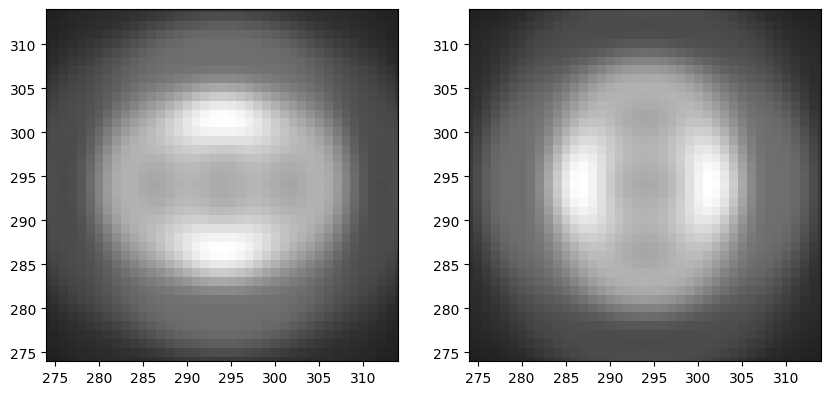

In [103]:
N_im = psf_jax.shape[-1]
fig, ax = plt.subplots(1,2)
size = 20
vmin=jnp.min(psf_jax[0,0])
vmax=jnp.max(psf_jax[0,0])
ax[0].imshow(psf_jax[0,0,0], cmap='gray', vmin=vmin, vmax=vmax)
ax[0].set_xlim((N_im//2-size,N_im//2+size))
ax[0].set_ylim((N_im//2-size,N_im//2+size))
ax[1].imshow(psf_jax[0,0,1], cmap='gray', vmin=vmin, vmax=vmax)
ax[1].set_xlim((N_im//2-size,N_im//2+size))
ax[1].set_ylim((N_im//2-size,N_im//2+size))

In [104]:
R = 400/120 # sphere radius in pixels

Z = psf_jax.shape[0]
H, W = psf_jax.shape[3], psf_jax.shape[4]

z = np.arange(Z) - Z // 2
y = np.arange(H) - H // 2
x = np.arange(W) - W // 2
zz, yy, xx = np.meshgrid(z, y, x, indexing='ij')  # zz: axis0-like, yy: axis3-like, xx: axis4-like
rr2 = xx**2 + yy**2 + (zz*30/120)**2

sphere3d = (rr2 < R**2).astype(float)
sphere3d /= sphere3d.sum()  # normalize to preserve flux

# sphere3d currently has shape (Z, H, W) — reshape to broadcast into
# vol's shape (Z, dim1, dim2, H, W), inserting singleton axes at 1 and 2
kern = sphere3d[:, None, None, :, :]
kern = jnp.broadcast_to(kern, psf_jax.shape)

kern = jnp.fft.ifftshift(kern, axes=(0, 3, 4))  # move center to index [0,0,0] along z,x,y

#plt.imshow(jnp.fft.fftshift(kern, axes=(0,3,4))[:, 0, 0, :, W//2])  # e.g. z-y slice through center

psf_conv = jnp.real(jnp.fft.ifftn(
    jnp.fft.fftn(psf_jax, axes=(0,3,4)) * jnp.fft.fftn(kern, axes=(0,3,4)),
    axes=(0,3,4)
))

(200.0, 400.0)

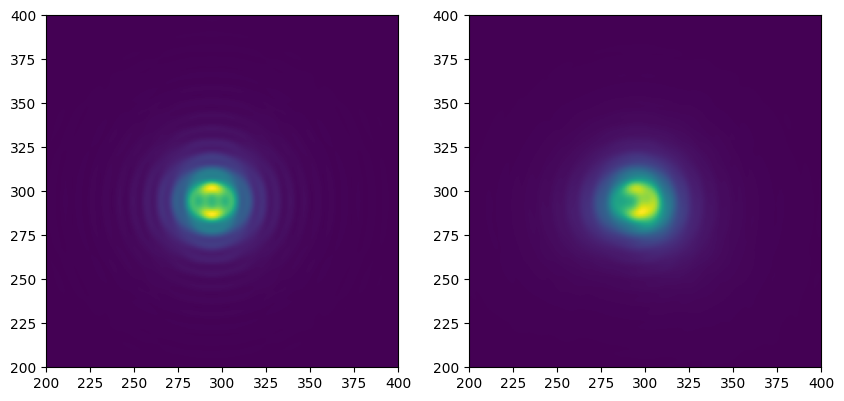

In [108]:
fig, ax = plt.subplots(1,2)
ax[0].imshow(psf_jax[0,0,0])
ax[0].set_xlim((200,400))
ax[0].set_ylim((200,400))
ax[1].imshow(psf_conv[0,0,0])
ax[1].set_xlim((200,400))
ax[1].set_ylim((200,400))

In [23]:
psf_jax.shape

(5, 3, 2, 588, 588)

In [24]:
Mj.shape

(5, 3, 2, 3, 3, 588, 588)

(62.0, 92.0)

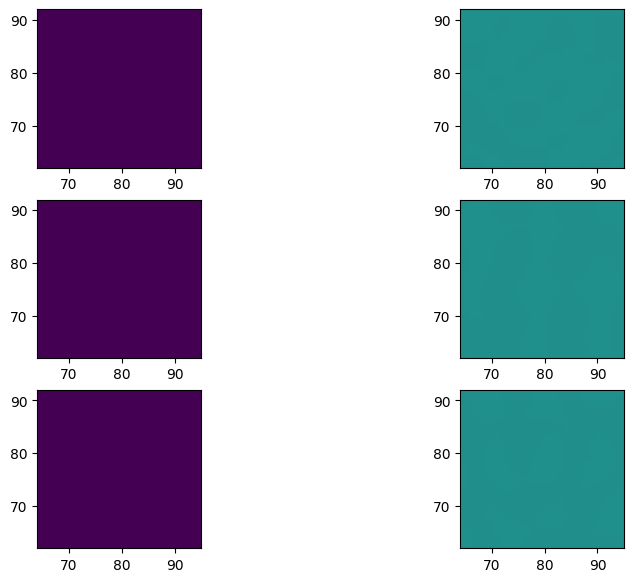

In [25]:
plt.rcParams['figure.figsize'] = [10,7]
fig, ax = plt.subplots(3,2)
ax[0,0].imshow(jnp.real(Mj[0,0,0,0,0]+Mj[0,0,0,0,0]))
ax[0,0].set_xlim((64,95))
ax[0,0].set_ylim((62,92))
ax[0,1].imshow(jnp.real(Mj[0,0,0,0,1]+Mj[0,0,0,1,0]))
ax[0,1].set_xlim((64,95))
ax[0,1].set_ylim((62,92))
ax[1,0].imshow(jnp.real(Mj[0,0,0,1,1]+Mj[0,0,0,1,1]))
ax[1,0].set_xlim((64,95))
ax[1,0].set_ylim((62,92))
ax[1,1].imshow(jnp.real(Mj[0,0,0,1,2]+Mj[0,0,0,2,1]))
ax[1,1].set_xlim((64,95))
ax[1,1].set_ylim((62,92))
ax[2,0].imshow(jnp.real(Mj[0,0,0,2,2]+Mj[0,0,0,2,2]))
ax[2,0].set_xlim((64,95))
ax[2,0].set_ylim((62,92))
ax[2,1].imshow(jnp.real(Mj[0,0,0,0,2]+Mj[0,0,0,2,0]))
ax[2,1].set_xlim((64,95))
ax[2,1].set_ylim((62,92))

In [ ]:
key = jax.random.PRNGKey(0)

In [ ]:
psf_noise_jax = noise_jax(key, psf_jax, QE=0.95, EM=200, b=5.0, sigma_b=0.1, sigma_r=1.0, bias=5.0)

In [ ]:
plt.imshow(psf_noise_jax[0,0,0])
plt.xlim((70,85))
plt.ylim((70,85))